In [ ]:
import pandas as pd
df = pd.read_csv('https://query.data.world/s/hsm3cqomcdjwvgkkpwpvhps6ia6svk?dws=00000')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
df.shape

(1310, 14)

In [ ]:
df.dtypes

,0
pclass,float64
survived,float64
name,object
sex,object
age,float64
sibsp,float64
parch,float64
ticket,object
fare,float64
cabin,object


<Axes: xlabel='survived', ylabel='count'>

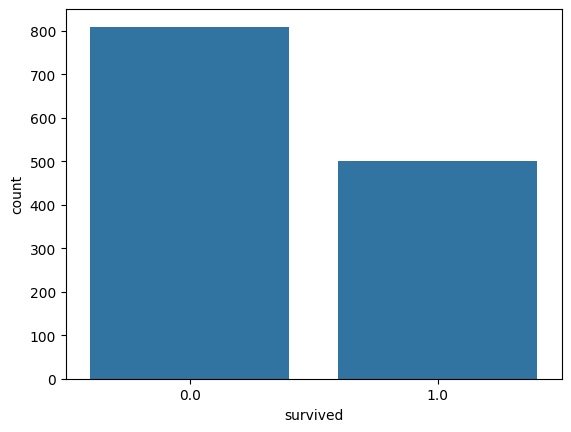

In [ ]:
import seaborn as sns
sns.countplot(x="survived",data=df)

<Axes: xlabel='survived', ylabel='count'>

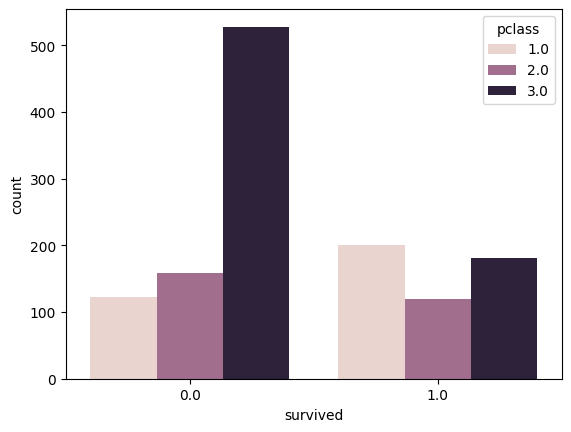

In [ ]:
sns.countplot(x="survived",hue="pclass",data=df)

<Axes: xlabel='survived', ylabel='count'>

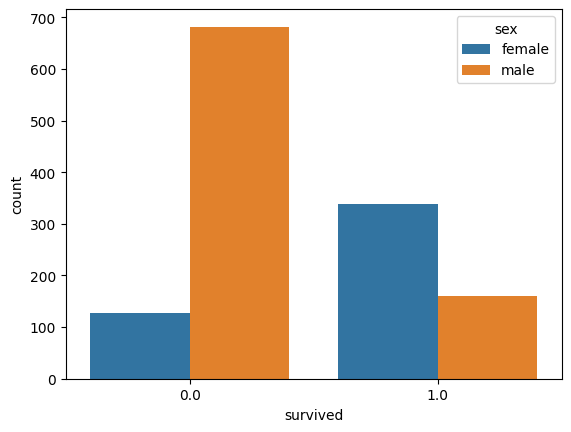

In [ ]:
sns.countplot(x="survived",hue="sex",data=df)

<Axes: ylabel='Frequency'>

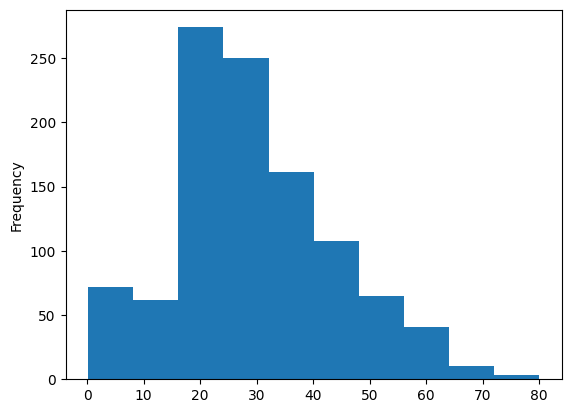

In [ ]:
df["age"].plot.hist()

<Axes: ylabel='Frequency'>

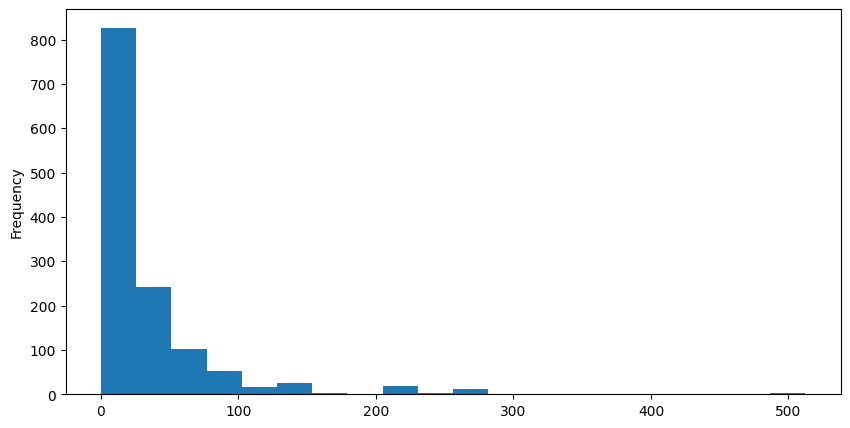

In [ ]:
df["fare"].plot.hist(bins=20,figsize=(10,5))

<Axes: xlabel='sibsp', ylabel='count'>

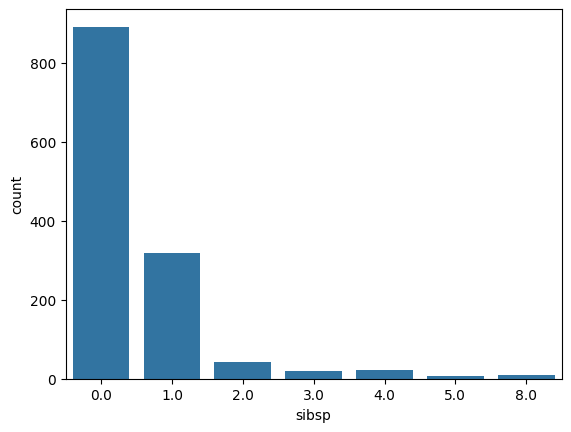

In [ ]:
sns.countplot(x="sibsp",data=df)

In [ ]:
df.isnull()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,False,False,False,False,True,False,False,False,False,True,False,True,True,True
1306,False,False,False,False,False,False,False,False,False,True,False,True,False,True
1307,False,False,False,False,False,False,False,False,False,True,False,True,True,True
1308,False,False,False,False,False,False,False,False,False,True,False,True,True,True


In [ ]:
df.isnull().sum()

,0
pclass,1
survived,1
name,1
sex,1
age,264
sibsp,1
parch,1
ticket,1
fare,2
cabin,1015


<Axes: >

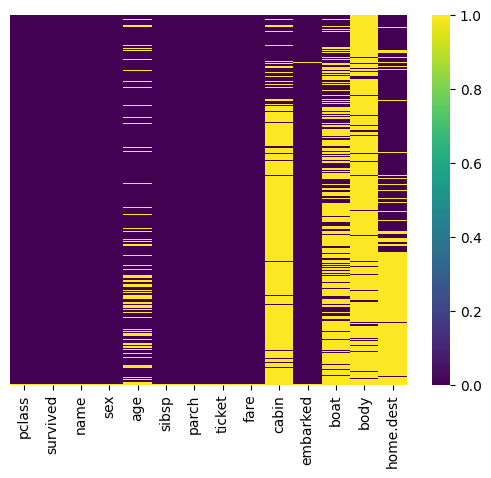

In [ ]:
sns.heatmap(df.isnull(),yticklabels=False,cmap="viridis")

In [ ]:
df.drop(["cabin","boat","body","home.dest"],axis=1,inplace=True)

In [ ]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,S
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,S
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,S
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,S
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,S


In [ ]:
df.isnull().sum()

,0
pclass,1
survived,1
name,1
sex,1
age,264
sibsp,1
parch,1
ticket,1
fare,2
embarked,3


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
embarked,0


In [ ]:
df.dtypes

,0
pclass,float64
survived,float64
name,object
sex,object
age,float64
sibsp,float64
parch,float64
ticket,object
fare,float64
embarked,object


In [22]:
sex=pd.get_dummies(df["sex"],drop_first=True)
sex.head()

,male
0,False
1,True
2,False
3,True
4,False


In [23]:
df.embarked.value_counts()

,count
embarked,
S,781
C,212
Q,50


In [27]:
embarked=pd.get_dummies(df["embarked"],drop_first=True)
pclass=pd.get_dummies(df["pclass"],drop_first=True)

In [28]:
df.drop(["sex","embarked","pclass"],axis=1,inplace=True)
df=pd.concat([df,sex,embarked,pclass],axis=1)
df.dtypes

,0
survived,float64
name,object
age,float64
sibsp,float64
parch,float64
ticket,object
fare,float64
male,bool
Q,bool
S,bool


In [29]:
df.drop(["name","ticket"],axis=1,inplace=True)
df.head()

,survived,age,sibsp,parch,fare,male,Q,S,2.0,3.0
0,1.0,29.0000,0.0,0.0,211.3375,False,False,True,False,False
1,1.0,0.9167,1.0,2.0,151.5500,True,False,True,False,False
2,0.0,2.0000,1.0,2.0,151.5500,False,False,True,False,False
3,0.0,30.0000,1.0,2.0,151.5500,True,False,True,False,False
4,0.0,25.0000,1.0,2.0,151.5500,False,False,True,False,False


In [30]:
X=df.drop("survived",axis=1)
y=df["survived"]

In [31]:
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=100)

In [40]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(max_iter=1000)
lg.fit(X_train.values, y_train)
lg.score(X_test.values, y_test)

0.7559808612440191

In [41]:
lg.score(X_train.values, y_train)

0.7997601918465228

In [42]:
lg01=LogisticRegression(C=0.1,max_iter=1000)
lg01.fit(X_train.values, y_train)
print(lg01.score(X_test.values, y_test))
print(lg.score(X_train.values, y_train))

0.7655502392344498
0.7997601918465228


In [43]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,lg.predict(X_test.values))

array([[98, 24],
       [27, 60]])

In [44]:
df.head()

,survived,age,sibsp,parch,fare,male,Q,S,2.0,3.0
0,1.0,29.0000,0.0,0.0,211.3375,False,False,True,False,False
1,1.0,0.9167,1.0,2.0,151.5500,True,False,True,False,False
2,0.0,2.0000,1.0,2.0,151.5500,False,False,True,False,False
3,0.0,30.0000,1.0,2.0,151.5500,True,False,True,False,False
4,0.0,25.0000,1.0,2.0,151.5500,False,False,True,False,False


In [50]:
import numpy as np
new_data=np.array([[29,0,0,211.3375,0,0,1,0,0]])
lg01.predict(new_data)

array([1.])

In [52]:
lg01.coef_

array([[-0.03410188, -0.34574272,  0.09024373,  0.0056453 , -1.84304257,
        -0.41325361, -0.40364783, -0.22370627, -1.08117625]])

In [53]:
data2=np.array([30,1,1,150,0,0,1,0,0])
lg01.predict([data2])

array([1.])